In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy
import numpy as np
import pandas
import matplotlib
import json
import re
import sentencepiece as spm
from tqdm.notebook import tqdm
import torch.optim as optim
from torchinfo import summary
from torch.utils.data import DataLoader, TensorDataset


import copy
import random
import os
import math

print(torch.__version__)
print(numpy.__version__)
print(pandas.__version__)
print(matplotlib.__version__)
print(json.__version__)
print(re.__version__)

2.10.0
2.4.2
3.0.0
3.10.8
2.0.9
2.2.1


In [3]:
class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

config = Config({
    'data_dir': 'data',
    'corpus_file': 'kowiki.txt',
    'pretrain_json_path': 'bert_pre_train3000.json',


    'n_seq': 128,
    "d_model": 128,
    "n_head": 4,
    "d_head": 64,
    "dropout": 0.1,
    "d_ff": 1024,
    "layernorm_epsilon": 0.001,
    "n_layer": 3,
    "n_vocab": 8007,
    "i_pad": 0,
    'n_train': 10000,
    "batch_size": 64,
    "epochs": 10
})


prefix = os.path.join(config.data_dir, 'ko_8000')
corpus_file = os.path.join(config.data_dir, config.corpus_file)

###  Tokenizer 준비
- SentencePiece 모델을 이용해 BERT의 MLM 학습용 데이터를 만드세요. 
- SentencePiece 모델 생성 (Vocab 8,000)

In [ ]:
spm.SentencePieceTrainer.train(
    f"--input={corpus_file} --model_prefix={prefix} --vocab_size={config.n_vocab } "
    f"--model_type=bpe --max_sentence_length=999999 "
    f"--pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] "
    f"--bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] "
    f"--user_defined_symbols=[SEP],[CLS],[MASK]"
)
print("SentencePiece Training Complete.")


In [4]:
# 생성된 모델 로드
vocab = spm.SentencePieceProcessor()
vocab.load(f"{prefix}.model")

# Masking 시 사용할 단어 목록 (특수문자 제외)
vocab_list = []
for id in range(7, len(vocab)):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))

        
print(f"Vocab size: {len(vocab)}")



Vocab size: 8007


### 데이터 전처리 (1) MASK 생성
- BERT의 MLM에 필요한 빈칸(mask)을 학습 데이터 전체 토큰의 15% 정도로 만들어 주세요.
- 그 중 80%는 [MASK] 토큰, 10%는 랜덤한 토큰, 나머지 10%는 원래의 토큰을 그대로 사용하세요.

In [5]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    BERT의 MLM 학습을 위한 마스킹 함수
    :param tokens: 토큰 리스트 (list of str)
    :param mask_cnt: 마스킹할 토큰의 개수 (전체 토큰의 약 15%)
    :param vocab_list: 랜덤 토큰 교체시 사용할 전체 단어 사전 리스트
    :return: (마스킹된 토큰 리스트, 마스크 인덱스 리스트, 정답 라벨 리스트)
    """
    
    # 1. 단어(어절) 단위 마스킹을 위해 인덱스 분할
    # SentencePiece의 '▁'(u"\u2581")는 새로운 단어의 시작을 의미함을 이용합니다.
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        # 새로운 단어의 시작이 아니라면(단어 중간 조각) 이전 단어 묶음에 추가
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # 2. 무작위 마스킹을 위해 단어 단위 인덱스 묶음을 섞습니다.
    random.shuffle(cand_idx)
    
    mask_lms = [] # 마스킹된 정보를 담을 리스트
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:  # 목표 개수에 도달하면 중단
            break
        if len(mask_lms) + len(index_set) > mask_cnt: # 단어 통째로 넣었을 때 개수가 넘으면 skip
            continue
        
        # 3. 15% 확률로 선택된 토큰들에 대해 80/10/10 법칙 적용
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8: # 80% : [MASK] 토큰으로 변경
                masked_token = "[MASK]"
            elif dice < 0.9: # 10% : 원래 토큰 유지
                masked_token = tokens[index]
            else: # 10% : 사전의 랜덤 토큰으로 교체
                masked_token = random.choice(vocab_list)
            
            # 정답 정보 저장 (인덱스 및 원래 토큰 값)
            mask_lms.append({"index": index, "label": tokens[index]})
            # 실제 토큰 리스트 수정
            tokens[index] = masked_token

    # 4. 마스크 인덱스 순서대로 정렬하여 결과 추출
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

# [사용 예시]
# tokens: 입력 토큰 리스트
# mask_cnt: int(len(tokens) * 0.15)
# vocab_list: 특수문자를 제외한 단어 사전 리스트
# tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)


### 데이터 전처리 (2) NSP pair 생성
- BERT의 pretrain task인 NSP는 두 문장이 연속하는지 확인하는 것입니다. 이를 위해 2개의 문장을 짝지어 50%의 확률로 TRUE와 FALSE를 지정해 주세요.
- 두 문장 사이에 segment 처리를 해주세요. 첫 번째 문장의 segment는 0, 두 번째 문장은 1로 채워준 후 둘 사이에 구분자인 [SEP] 등을 넣어주세요.
- MLM과 NSP는 동시에 학습된다는 것을 염두에 두고 학습 데이터를 구성해 보세요.

In [6]:
# 데이터 전처리 (2) NSP pair 생성 및 MLM 통합 
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    두 문장의 총 합이 max_seq를 넘지 않도록 길이를 조절합니다.
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0] # 앞쪽을 삭제 (문맥 유지)
        else:
            tokens_b.pop()  # 뒤쪽을 삭제

def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    문서(doc)로부터 NSP 및 MLM이 적용된 학습 인스턴스를 생성합니다.
    :param n_seq: 모델이 수용하는 최대 시퀀스 길이
    :param mask_prob: 마스킹 확률 (보통 0.15)
    """
    # [CLS], [SEP], [SEP] 3개의 특수 토큰 자리를 제외한 최대 길이
    max_seq = n_seq - 3

    instances = []
    current_chunk = []   # 현재 모으고 있는 문장 조각들
    current_length = 0    # 현재 조각들의 총 토큰 수

    for i in range(len(doc)):
        current_chunk.append(doc[i]) # 문장 단위 토큰 리스트 추가
        current_length += len(doc[i])
        
        # 마지막 문장이거나, 현재 모은 토큰이 max_seq를 넘어가면 데이터 생성 시작
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            
            # 1. 두 문장 덩어리(A, B)로 나눌 지점을 무작위로 결정
            a_end = random.randrange(1, len(current_chunk))
            
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            # 2. 50% 확률로 NSP (Next Sentence Prediction) 처리
            if random.random() < 0.5:
                is_next = 0    # False (연속되지 않은 문장으로 위장)
                # 두 문장의 순서를 바꿉니다 (Swap)
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1    # True (실제 연속된 문장)

            # 3. 최대 길이를 넘지 않도록 토큰 수 조절
            trim_tokens(tokens_a, tokens_b, max_seq)
            
            # 4. BERT 입력 형식 구성: [CLS] A [SEP] B [SEP]
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            # 5. Segment ID 생성: A 영역은 0, B 영역은 1
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            # 6. MLM 마스킹 수행 (동시 학습을 위해 여기서 호출)
            # (마스킹 개수 = 특수 토큰을 제외한 순수 토큰 수의 15%)
            mask_cnt = int((len(tokens) - 3) * mask_prob)
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

            # 최종 학습 데이터 인스턴스 저장
            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,        # NSP 정답
                "mask_idx": mask_idx,      # MLM 마스크 위치
                "mask_label": mask_label    # MLM 원래 단어 정답
            }
            instances.append(instance)

            # 다음 인스턴스를 위해 초기화
            current_chunk = []
            current_length = 0
            
    return instances


In [7]:
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던
설렁탕 한 그릇을 이제는 살 수 있어
집으로 돌아가는 길 난 문득 떠올라
아내의 목소리가 거칠어만 가는 희박한 숨소리가
오늘은 왠지 나가지 말라던 내 옆에 있어 달라던
그리도 나가고 싶으면 일찍이라도 들어와 달라던
아내의 간절한 목소리가 들려와
나를 원망하듯 비는 점점 거세져
싸늘히 식어가는 아내가 떠올라 걱정은 더해져
난 몰라 오늘은 운수 좋은 날
난 맨날 이렇게 살 수 있으면 얼마나 좋을까"""

doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]
print(vocab_list)
print(doc)

# 최대 길이
n_test_seq = 64


instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)

['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다', '었다', '▁지', '▁수', '▁19', '▁가', '▁시', '▁20', '▁기', '▁전', '▁아', '▁하', '▁있다', '▁다', '▁제', '했다', '하였', '▁일', '▁한', '▁중', '▁정', '▁주', '하는', '▁것', '▁자', '▁공', '▁인', '되었다', '▁경', '▁위', '▁유', '▁보', '하고', '▁3', '▁등', '▁부', '하였다', '▁조', '하여', '▁미', '▁동', '▁선', '▁나', '으며', '▁모', '▁연', '▁영', '▁의', '▁오', '▁마', '에는', '▁발', '▁소', '한다', '▁고', '▁개', '▁201', '▁구', '▁세', '▁도', '▁상', '▁비', '▁스', '▁국', '▁서', '▁후', '▁여', '▁200', '▁때', '▁4', '▁성', '▁해', '▁관', '▁있는', '▁신', '▁프', '▁대한', '부터', '▁5', '00', '▁방', '▁또', '지만', '▁(', '▁역', '되어', '▁않', '▁만', '▁"', '▁장', '▁바', '까지', '▁무', '▁남', '▁통', '▁현', '▁교', '▁같', '에게', '▁내', '학교', '▁문', '▁출', '▁거', '▁포', '▁결', '된다', '▁《', '적인', '이라', '▁6', '▁우', '적으로', '▁불', '▁원', '▁최', '▁진', '▁생', '▁작', '▁어', '▁당', '국의', '▁노', '▁강', '▁알', '▁반', '▁7', '▁8', '▁계', '▁따', '▁파', '▁분', '▁없', '▁받', '▁말', '면서', '들이', 'or', '되었', '▁사용', "▁'", '▁두', '▁실', '에서는', '▁10', '▁리', '들은', '▁명', '▁함', '▁단', '▁이후', '하기', '▁예', '년에', '),',

### 데이터 전처리 (3) 데이터셋 완성
- BERT pretrain 데이터셋을 생성해, json 포맷으로 저장하세요. 데이터셋의 사이즈가 크므로np.memmap을 사용해 메모리 사용량을 최소화해 보세요.

In [8]:
# Q. 아래 주석에 따라 코드를 완성해주세요.
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):        # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)
                doc = []

In [9]:
make_pretrain_data(vocab, corpus_file, config.pretrain_json_path, config.n_seq)

  0%|          | 0/3957761 [00:00<?, ?it/s]

In [10]:
# 데이터 전처리 (3) 데이터셋 완성 및 np.memmap 생성
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    JSON 파일을 읽어 학습에 최적화된 np.memmap 데이터셋으로 변환합니다.
    :param vocab: SentencePiece 모델
    :param filename: 앞서 생성한 json 파일 경로
    :param n_seq: 최대 시퀀스 길이 (예: 128)
    :param count: 처리할 데이터 개수 제한 (None이면 전체 처리)
    """
    
    # 1. 전체 데이터 개수 파악 (memmap의 전체 shape을 결정하기 위함)
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            if count is not None and total >= count:
                break

    # 2. np.memmap을 사용하여 디스크에 저장될 바이너리 파일 생성
    # 메모리에 수십만 건을 다 올리는 대신, 필요할 때마다 디스크에서 읽어옵니다.
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    # 3. JSON 데이터를 읽어 숫자 ID로 변환 후 memmap에 기록
    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if i >= total:
                break
            
            data = json.loads(line)
            
            # (1) Token -> ID 변환 및 Padding 수행
            # vocab.piece_to_id를 사용하여 문자열 조각을 숫자로 바꿉니다.
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))  # 0번(PAD)으로 패딩
            
            # (2) Segment ID (0 또는 1) 및 Padding
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            
            # (3) NSP Label (0 또는 1)
            label_nsp = data["is_next"]
            
            # (4) MLM Label 생성 (마스킹된 위치에만 원래 정답 ID 저장, 나머지는 0)
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            # 검증: 모든 시퀀스 길이는 n_seq와 같아야 함
            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            # memmap 객체에 실시간 기록 (디스크로 즉시 동기화)
            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)


In [11]:
# [실행 예시]
## 128000건만 메모리에 로딩
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, config.pretrain_json_path, config.n_seq, count=128000)

## 첫 번째 샘플(0번 인덱스)에서 단어 ID 확인
#input_ids = pre_train_inputs[0][0] 
# 첫 번째 샘플에서 문장 소속 확인 (0은 A, 1은 B)
#segments = pre_train_inputs[0][1] 

# 생성된 파일 확인
print(pre_train_inputs[0][0])  # 첫 번째 데이터의 인코딩된 토큰들

# input_ids = pre_train_inputs[0][0] 
# # => [5, 102, 34, 4, 203, 11, 4, 0, 0, 0] 
# # (CLS 학교 간다 SEP 공부 한다 SEP PAD PAD PAD)
# segments = pre_train_inputs[0][1] 
# # => [0, 0, 0, 0, 1, 1, 1, 0, 0, 0] 
# # (A  A  A  A  B  B  B  PAD PAD PAD)


# pre_train_labels[0][0] --> labels_nsp
# pre_train_labels[0][1] --> labels_mlm

# input_ids (문제):

# [5, 10, 6, 20, 6, 0, 0, ...]
# (6번(MASK)이 2개 뚫렸네요!)
# labels_mlm (정답):

# [0, 0, 1023, 0, 45, 0, 0, ...]
# (3번째 자리에 원래 1023번 단어가 있었고, 5번째 자리에 45번 단어가 있었다는 정답입니다!)

  0%|          | 0/128000 [00:00<?, ?it/s]

[   5   10 1607 3599 1756 3630   41 3644  830 3624 1135   52 3599   13
   81    6    6 2247   25 3779 3873 3667 3631 3813 3873 4196 3636 3779
 3601  249 3725 1233   33   52 3599  479 3652 3625  243 2780   14 1510
  168 3877  414  166 1697 4290 3873 3703 3683  593   21 5007    6 1928
 3607  813   17 3599  307  587  930    6    6    6  613 3638 3718   99
 3878 3656  256 2543  309  337 3735  181 3616 3603  489  376 3599    4
    6    6    6    6 3324 1042  104 3610 3686 3718  207 3714   37 3417
  416  810 3666 3625  160 3662    6    6  203  241 3602 1114 3724  788
    6   49 3632  796  663 1648 3682 3682 3625    6 3009 3625 3616   16
 3599    4]


## BERT 모델 구현
- pad mask, ahead mask 함수, gelu activation 함수, parameter initializer 생성 함수, json을 config 형태로 사용하기 위한 유틸리티 함수를 먼저 만들어 두세요.
- Embedding 레이어, Transformer encoder 레이어, BERT 레이어를 구성한 후, pretraine용 BERT 모델을 만들어 봅시다.

In [12]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask


def gelu(x):
    """
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))


def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return torch.nn.init.trunc_normal_


def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_


In [13]:
class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        # 단어 사전의 개수(예: 32,000개)를 저장합니다.
        self.n_vocab = config.n_vocab
        # 모델이 단어를 표현할 벡터의 크기(예: 768)를 저장합니다.
        self.d_model = config.d_model
        # self.shared_weights: (단어 수, 벡터 크기) 모양의 커다란 행렬을 하나 만듭니다. 이게 바로 공유될 보물 지도입니다.
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        # 생성된 빈 행렬을 절단 정규분포(0 주변의 값)로 초기화합니다. (BERT의 표준 초기화 방식입니다.)
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        # mode가 embedding일 경우 embedding lookup 실행
        if mode == "embedding":
            return self._embedding(inputs)
        # mode가 linear일 경우 linear 실행
        elif mode == "linear":
            return self._linear(inputs)
        # mode가 기타일 경우 오류 발생
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)

        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs



class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        position = position.long()
        embed = self.embedding(position)
        return embed


In [14]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out




# Q. 주석과 코드를 참조하여 아래 클래스를 완성해주세요.
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)

        return attn_out

In [15]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val



class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out


In [16]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed




In [17]:
# Encoder Layer class 정의
# 이 클래스는 BERT가 문제를 다 풀고 나서 "최종 정답(NSP 등)을 결정하는 판사님" 역할을 합니다.
# 사과라는 단어의 768개 숫자들에 대해서만 평균을 내고 정규화한다. 그 옆의 학교라는 단어는 또 자기 숫자들끼리 따로 정규화한다. 

class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: softmax된 결과
        """
        outputs = F.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        # outputs = F.softmax(outputs, dim=-1)
        return outputs


class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        logits_cls = self.pooled_output(logits_cls)
        # outputs_nsp = F.softmax(logits_cls, dim=-1)
        outputs_nsp = logits_cls

        # outputs_mlm = F.softmax(logits_lm, dim=-1)
        outputs_mlm = logits_lm
        return outputs_nsp, outputs_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() 
                      else "mps" if torch.backends.mps.is_available() 
                      else "cpu")


pre_train_model = build_model_pre_train(config)


summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)])
pre_train_model.to(device)


PreTrainModel(
  (bert): BERT(
    (embedding): SharedEmbedding()
    (position): PositionEmbedding(
      (embedding): Embedding(128, 128)
    )
    (segment): Embedding(2, 128)
    (norm): LayerNorm((128,), eps=0.001, elementwise_affine=True)
    (encoder_layers): ModuleList(
      (0-2): 3 x EncoderLayer(
        (self_attention): MultiHeadAttention(
          (W_Q): Linear(in_features=128, out_features=256, bias=True)
          (W_K): Linear(in_features=128, out_features=256, bias=True)
          (W_V): Linear(in_features=128, out_features=256, bias=True)
          (attention): ScaleDotProductAttention()
          (W_O): Linear(in_features=256, out_features=128, bias=True)
        )
        (norm1): LayerNorm((128,), eps=0.001, elementwise_affine=True)
        (ffn): PositionWiseFeedForward(
          (W_1): Linear(in_features=128, out_features=1024, bias=True)
          (W_2): Linear(in_features=1024, out_features=128, bias=True)
          (gelu): GELU(approximate='none')
        

## pretrain 진행
- loss, accuracy 함수를 정의하고 Learning Rate 스케쥴링을 구현한 후, 10 Epoch까지 모델 학습을 시켜보세요. 
- 학습을 진행할 때는 배치 사이즈에 유의하세요.

In [20]:
def lm_loss(y_true, y_pred):
    """
    MLM 손실 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """

    y_true = y_true.long() 
    
    # 1. CrossEntropy 계산 (reduction='none'을 사용하여 각 토큰별 loss를 구함)
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    
    # 2. 정답이 0인 부분(마스킹 안 된 곳)은 손실 계산에서 제외 (mask 생성)
    mask = (y_true != 0).float()
    loss = loss * mask.view(-1)
    
    # 3. 평균을 낸 뒤 20배를 곱하여 MLM 학습 효율을 높임
    return loss.mean() * 20


In [ ]:
def lm_acc(y_true, y_pred):
    """
    MLM 정확도(Accuracy) 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # 모델 입력값 (입력된 토큰 ID들): [ 5, 203, 6, 114, 6, 89, 4, 0, 0, 0 ]  (여기서 6번이 [MASK] 토큰의 ID라고 가정합니다)
    # y_true (우리가 만든 정답지): [ 0, 0, 1023, 0, 45, 0, 0, 0, 0, 0 ] (원래 '학교에'의 단어 ID가 1023번, '밥을'의 단어 ID가 45번이었다고 가정)


    # 1. 예측값에서 가장 높은 확률을 가진 인덱스(단어 ID) 추출
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    
    # 2. 정답(y_true)과 예측값(y_pred_class)이 일치하는지 확인 (T/F -> 1/0)
    matches = (y_true == y_pred_class).float()
    
    # 3. 정답이 0인 부분(마스킹 안 된 곳)은 계산에서 제외하기 위한 마스크 생성
    mask = (y_true != 0).float()
    
    # 4. 실제 마스킹된 위치의 일치 여부만 남김
    matches *= mask
    
    # 5. (맞춘 개수 / 실제 마스킹된 총 개수)로 정확도 계산
    # mask.sum()이 0일 경우를 대비해 clamp(min=1)로 나누기 오류 방지
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    
    return accuracy

In [22]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        return self.get_lr()

In [23]:
train_inputs = [torch.as_tensor(x[:config.n_train]).long().to(device) for x in pre_train_inputs]
train_labels = [torch.as_tensor(x[:config.n_train]).long().to(device) for x in pre_train_labels]

# 자른 데이터를 이용해서 Dataset과 DataLoader 생성
train_dataset = TensorDataset(train_inputs[0], train_inputs[1], train_labels[0], train_labels[1])
train_dataloader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
print(f"✅ 사용될 데이터셋 훈련 길이: {len(train_dataset)}")


✅ 사용될 데이터셋 훈련 길이: 10000


In [24]:
# optimizer
train_steps = math.ceil(len(train_dataset) / config.batch_size) * config.epochs
print("train_steps:", train_steps)
learning_rate_scheduler = CosineSchedule(train_steps=train_steps, warmup_steps=max(100, train_steps // 10))
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = lm_loss

train_steps: 1570


In [25]:
pre_train_model.to(device)
history = {
    "nsp_loss": [],
    "mlm_loss": [],
    "nsp_acc": [],
    "mlm_acc": []
}

for epoch in range(config.epochs):
    pre_train_model.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{config.epochs}"):
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = lm_loss(labels_mlm_batch, logits_mlm)

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        optimizer.step()
        lr = learning_rate_scheduler.step()
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        
        # accuracy
        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_accuracy = lm_acc(labels_mlm_batch, logits_mlm)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_accuracy.item()

    # 결과 저장
    history["nsp_loss"].append(total_nsp_loss / len(train_dataloader))
    history["mlm_loss"].append(total_mlm_loss / len(train_dataloader))
    history["nsp_acc"].append(total_nsp_acc / len(train_dataloader))
    history["mlm_acc"].append(total_mlm_acc / len(train_dataloader))

    print(f"Epoch {epoch+1}/{config.epochs} - Loss: {total_loss / len(train_dataloader):.4f}, "
          f"NSP Loss: {total_nsp_loss / len(train_dataloader):.4f}, MLM Loss: {total_mlm_loss / len(train_dataloader):.4f}, "
          f"NSP Accuracy: {total_nsp_acc / len(train_dataloader):.4f}, MLM Accuracy: {total_mlm_acc / len(train_dataloader):.4f}")

    # 모델 저장
    torch.save(pre_train_model.state_dict(), f"mini_bert_pre_train_epoch_{epoch+1}.pt")


Epoch 1/10:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 22.9194, NSP Loss: 0.6674, MLM Loss: 22.2520, NSP Accuracy: 0.5637, MLM Accuracy: 0.0219


Epoch 2/10:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 2/10 - Loss: 20.3798, NSP Loss: 0.6606, MLM Loss: 19.7192, NSP Accuracy: 0.5655, MLM Accuracy: 0.0280


Epoch 3/10:   0%|          | 0/157 [00:00<?, ?it/s]

...

Epoch 8/10 - Loss: 20.1293, NSP Loss: 0.6333, MLM Loss: 19.4961, NSP Accuracy: 0.5703, MLM Accuracy: 0.0281


Epoch 9/10:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 20.1124, NSP Loss: 0.6314, MLM Loss: 19.4810, NSP Accuracy: 0.5778, MLM Accuracy: 0.0286


Epoch 10/10:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 20.1099, NSP Loss: 0.6305, MLM Loss: 19.4794, NSP Accuracy: 0.5768, MLM Accuracy: 0.0286


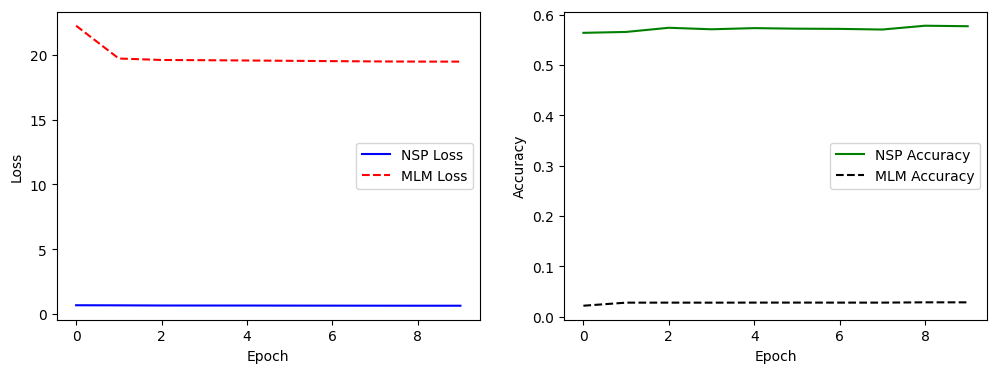

In [26]:
import matplotlib.pyplot as plt
%matplotlib inline

# training result
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["nsp_loss"], "b-", label="NSP Loss")
plt.plot(history["mlm_loss"], "r--", label="MLM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["nsp_acc"], "g-", label="NSP Accuracy")
plt.plot(history["mlm_acc"], "k--", label="MLM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## 💡 회고 (Retrospective)
### 1. 이번 프로젝트를 하면서 느낀 점과 배운 점
* **Bert**: 오직 디코더(Encoder) 1채로만 구성된 Bert 아키텍쳐를 소스레벨에서 구현 확인해 볼수 있어서 좋았습니다.
* **전처리**: 전처리 과정이 GPT나 트랜스포머와 다른 과정이어서 흥미로왔습니다. 

### 2. 이번 프로젝트에서 잘했다고 생각하는 점
* **대용량 데이터셋 메모리 최적화 (np.memmap)**: 청난 크기가 될 수밖에 없는 사전학습(Pre-training) 데이터셋의 특성을 고려하여, 전체 데이터를 메모리(RAM)에 다 올리지 않고 np.memmap을 활용해 디스크에서 필요한 배치만큼만 읽어오도록 효율적인 로딩 파이프라인을 구축해 냈습니다.

### 3. 이번 프로젝트에서 느낀 문제점 및 한계점
* **훈련량 부족**: 에포크가 10밖에 안되서 그냥 로스가 줄어든것과 Accuracy가 올라간것에 의의를 듭니다.


### 4. 다음 프로젝트/실무를 위해 개선해야 할 점 (Action Items)
* **HuggingFace 진성 가중치 활용(Transfer Learning)**: 이번 실습에서는 BERT의 엔진과 뼈대를 밑바닥부터 만드는 "Pre-training"에 초점을 맞추었습니다. 다음 단계에서는 이미 수백 기가의 데이터로 완벽히 사전학습이 끝난 KoBERT나 klue/bert-base 같은 거대 모델의 진짜 가중치를 가져와서, 감성 분석이나 분류 모델 같은 실제 응용 단계(Downstream Task)의 Fine-tuning에 직접 투입해 보겠습니다.
